In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df=pd.read_csv('/content/archive.zip')

In [10]:
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [11]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [13]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [14]:
df['person_emp_length']=df['person_emp_length'].fillna(df['person_emp_length'].median())

In [15]:
df['loan_int_rate']=df['loan_int_rate'].fillna(df['loan_int_rate'].median())

In [16]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

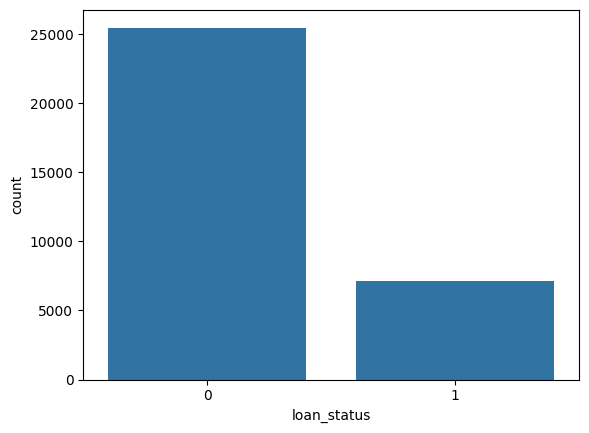

In [17]:
sns.countplot(x='loan_status', data=df)
plt.show()

## Insight:
“The dataset is biased toward the non-default class, with a higher proportion of observations belonging to loan_status = 1.”

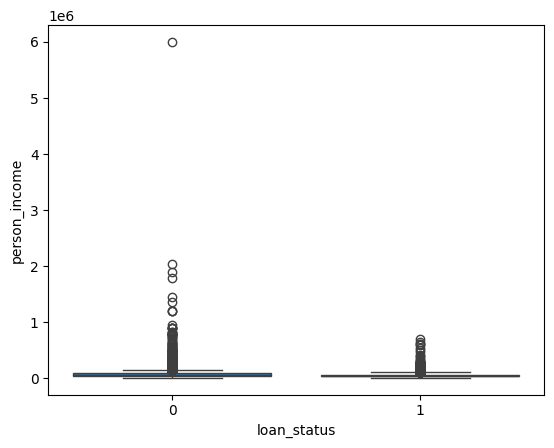

In [18]:
sns.boxplot(x='loan_status', y='person_income', data=df)
plt.show()

## Insight:
“The distribution indicates a higher presence of outliers in the loan_status = 0 group compared to loan_status = 1, suggesting greater variability and potentially higher-risk profiles within this category.”

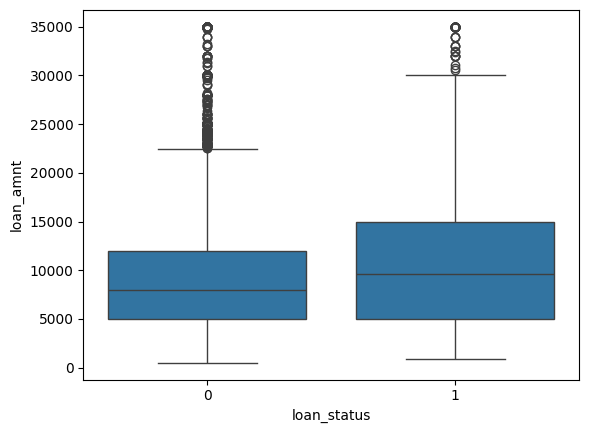

In [19]:
sns.boxplot(data=df,x='loan_status',y='loan_amnt')
plt.show()

## Insight:
“A higher number of outliers is observed in the non-default category compared to the default group.”

In [20]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [21]:
df['loan_income_ratio'] = df['loan_amnt'] / df['person_income']

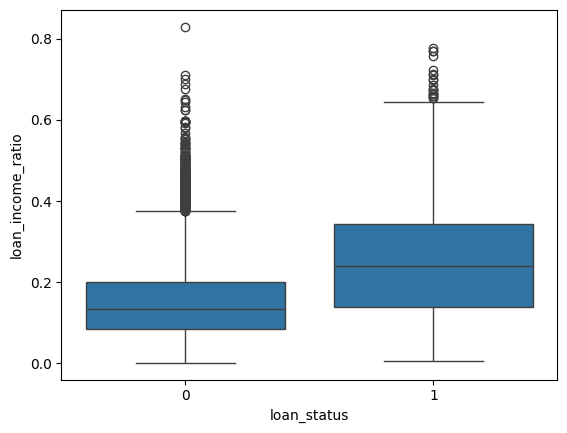

In [22]:
sns.boxplot(x='loan_status', y='loan_income_ratio', data=df)
plt.show()

## Insight:
“Higher loan-to-income ratios are associated with an increased likelihood of default or loan rejection.”

In [23]:
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].apply(lambda x:1 if  x=='Y' else 0)

In [24]:
df['person_home_ownership'].unique()

array(['RENT', 'OWN', 'MORTGAGE', 'OTHER'], dtype=object)

In [25]:
df['person_home_ownership'] = df['person_home_ownership'].replace({'RENT': 1,'OWN':2,'MORTGAGE':3,'OTHER': 4})

/tmp/ipykernel_26205/2329128959.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['person_home_ownership'] = df['person_home_ownership'].replace({'RENT': 1,'OWN':2,'MORTGAGE':3,'OTHER': 4})


In [26]:
df['loan_intent'].unique()

array(['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT',
       'DEBTCONSOLIDATION'], dtype=object)

In [27]:
df['loan_intent']=df['loan_intent'].replace({'PERSONAL':1,'EDUCATION':2,'MEDICAL':3,'VENTURE':4,'HOMEIMPROVEMENT':5,'DEBTCONSOLIDATION':6})

/tmp/ipykernel_26205/2412190144.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['loan_intent']=df['loan_intent'].replace({'PERSONAL':1,'EDUCATION':2,'MEDICAL':3,'VENTURE':4,'HOMEIMPROVEMENT':5,'DEBTCONSOLIDATION':6})


In [28]:
df['loan_grade'].unique()

array(['D', 'B', 'C', 'A', 'E', 'F', 'G'], dtype=object)

In [29]:
df['loan_grade']=df['loan_grade'].replace({'A':1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7})

/tmp/ipykernel_26205/2251171507.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['loan_grade']=df['loan_grade'].replace({'A':1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7})


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  int64  
 3   person_emp_length           32581 non-null  float64
 4   loan_intent                 32581 non-null  int64  
 5   loan_grade                  32581 non-null  int64  
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               32581 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  int64  
 11  cb_person_cred_hist_length  32581 non-null  int64  
 12  loan_income_ratio           32581 non-null  float64
dtypes: float64(4), int64(9)
memory 

In [31]:
X=df[['person_income','person_emp_length','loan_grade','person_home_ownership','loan_intent','loan_amnt','loan_int_rate','cb_person_default_on_file','cb_person_cred_hist_length','loan_income_ratio']]
y=df['loan_status']

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train ,X_test ,y_train , y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [34]:
from sklearn.linear_model import LogisticRegression

In [35]:
model1 = LogisticRegression()

In [36]:
X_train.shape

(26064, 10)

In [37]:
X_test.shape

(6517, 10)

In [38]:
model1.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [39]:
print(model1.coef_)
print(model1.intercept_)

[[-3.38680065e-05 -3.33381641e-02  5.53901816e-01 -5.65584053e-01
  -1.37730110e-01  1.10201752e-04 -8.03677620e-03  1.12530914e-01
   4.25041079e-03 -3.13868998e-03]]
[-0.17258258]


In [40]:
train_pred=model1.predict_proba(X_train)
test_pred=model1.predict_proba(X_test)

In [41]:
train_class_pred=model1.predict(X_train)
test_class_pred=model1.predict(X_test)

In [42]:
from sklearn.metrics import confusion_matrix

In [43]:
cm=confusion_matrix(y_train,train_class_pred)

In [44]:
print(cm)

[[19489   912]
 [ 3399  2264]]


Text(0.5, 1.0, 'Confusion Matrix')

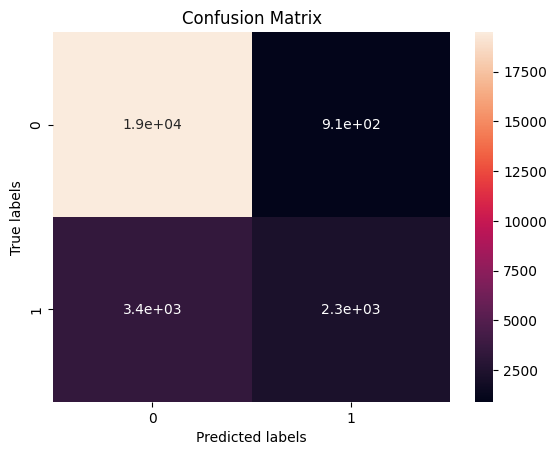

In [45]:
ax=plt.subplot()
sns.heatmap(cm,annot=True,ax=ax)
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')

Text(0.5, 1.0, 'Confusion Matrix')

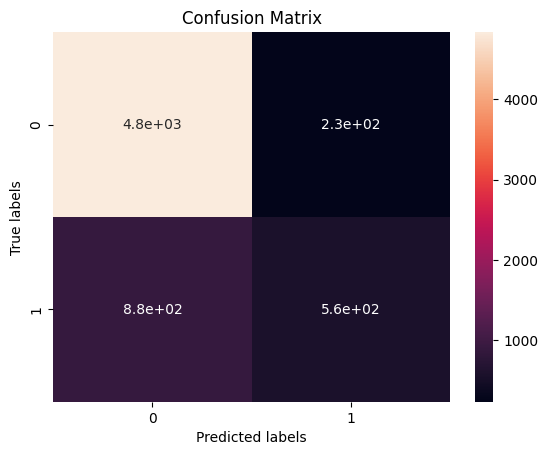

In [46]:
cm=confusion_matrix(y_test,test_class_pred)
ax=plt.subplot()
sns.heatmap(cm,annot=True,ax=ax)
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')

In [47]:
from sklearn.metrics import classification_report

In [48]:
print(classification_report( y_test,test_class_pred))

              precision    recall  f1-score   support

           0       0.85      0.95      0.90      5072
           1       0.71      0.39      0.50      1445

    accuracy                           0.83      6517
   macro avg       0.78      0.67      0.70      6517
weighted avg       0.82      0.83      0.81      6517



## Conclusion-


In this project, a logistic regression model was developed to predict loan default (`loan_status`) using borrower and loan-related features such as income, employment length, credit history, loan amount, interest rate, and income ratios. The dataset was preprocessed by converting categorical variables into numerical form and selecting relevant features to avoid redundancy and leakage.

The model achieved strong overall accuracy and performed well in identifying non-default cases. However, evaluation using the confusion matrix revealed a key limitation: the model struggles to detect defaulters. Specifically, it achieved relatively low recall for the default class (around 40%), meaning a significant number of risky borrowers were incorrectly classified as safe.

This issue is primarily due to class imbalance in the dataset, where non-default cases significantly outnumber default cases. As a result, the model becomes biased toward predicting the majority class, leading to misleadingly high accuracy but weaker real-world usefulness.

In practical credit risk applications, correctly identifying defaulters is more important than overall accuracy. Therefore, while the current model serves as a good baseline, it is not sufficient for real-world deployment without further improvements.

Future enhancements could include adjusting the decision threshold, applying class weighting, or using resampling techniques to better handle class imbalance. These approaches would help improve the model’s ability to detect high-risk borrowers and make more reliable credit decisions.
